In [2]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import random
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import precision_recall_curve, auc
#from common_utilities import *

2024-10-14 10:49:27.377580: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-14 10:49:27.385121: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-14 10:49:27.443137: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-14 10:49:27.514627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-14 10:49:27.599719: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

**Common utilities**

In [162]:
def get_balance(imbalanced_set):
    true_set = imbalanced_set[imbalanced_set['interaction']==1]
    false_set = imbalanced_set[imbalanced_set['interaction']==0]

    false_selected_indices = random.sample(list(false_set.index), k=true_set.shape[0])
    selected_false_set = false_set.loc[false_selected_indices]
    balanced_set = pd.concat([true_set, selected_false_set], ignore_index=True)
    return balanced_set

In [4]:
def prepare_data(data):
   # data['size'] = data['size'].astype(str)
   # data_dummies = pd.get_dummies(data, columns=['size'])
    # X = data_dummies.drop(['sample', 'regulator', 'target', 'interaction', 'size'], axis=1).values
    # y = data_dummies['interaction'].values
    X = data.drop(['sample', 'regulator', 'target', 'interaction', 'size'], axis=1).values
    y = data['interaction'].values
    X = np.asarray(X).astype(np.float32)
    y = np.asarray(y).astype(np.float32)
    return X, y

In [214]:
def performance_metrics(y, y_predicted):
    tp=fp=tn=fn=0
    for i in range(len(y)):
        if y[i]==y_predicted[i]:
            if y[i]==1:
                tp+=1
            else:
                tn+=1
        else:
            if y[i]==1:
                #fp+=1
                fn+=1
            else:
                #fn+=1
                fp+=1
    precision = tp/(tp+fp) if (tp+fp)!=0 else 0
    recall = tp/(tp+fn) if (tp+fn)!=0 else 0
    structural = (tp+tn)/(tp+fp+fn+tn)
    tpr = recall
    fpr = fp/(fp+tn) if (fp+tn)!=0 else 1
    aupr = auc(recall, precision)
    if precision==0 and recall==0:
        f1 = 0
    else:
        f1 = 2*precision*recall/(precision+recall)
    return precision, recall, structural, tpr, fpr, f1, aupr

In [216]:
def get_performace(_test_set, y_predicted):
    test_set = _test_set.copy()
    test_set['predicted'] = y_predicted
    result={}
    sample = set(test_set['sample'].values)
    for sp in sample:
        network = test_set[test_set['sample']==sp]
        p,r,st, tpr, fpr, f1, aupr = performance_metrics(network['interaction'].values, network['predicted'].values)
        result[f'{sp}'] = {'precision':round(p, 4), 'recall':round(r,4), 'structural': round(st,4), 
                           'tpr':round(tpr, 4), 'fpr':round(fpr, 4), 'f1':round(f1, 4), 'aupr':round(aupr, 4)}
    return result

In [170]:
def get_round(y_predicted, threshold=0.3):
    rounded_predicted = np.where(y_predicted >= threshold, np.ceil(y_predicted), np.floor(y_predicted))
    
    return rounded_predicted

In [172]:
def get_roc_curve(y, y_predicted):
    tp=fp=tn=fn=0
    for i in range(len(y)):
        if y[i]==y_predicted[i]:
            if y[i]==1:
                tp+=1
            else:
                tn+=1
        else:
            if y[i]==1:
                fp+=1
            else:
                fn+=1
    TPR = tp/(tp+fn)
    FPR = fp/(fp+tn)
    return TPR, FPR

**Load training, validation, and test set**

In [6]:
training_set = pd.read_csv(r'./caocao/training/size10.csv', index_col=0)

In [147]:
a = pd.read_csv(r'./caocao/Dream4/size10_1.csv', index_col=0)

In [149]:
a.shape

(450, 47)

In [8]:
training_set_50_1 = pd.read_csv(r'./caocao/training/size50_10.csv', index_col=0)

In [9]:
training_set_50_2 = pd.read_csv(r'./caocao/training/size50_20.csv', index_col=0)

In [10]:
training_set_50_1_true = training_set_50_1[training_set_50_1['interaction']==1]
training_set_50_2_true = training_set_50_2[training_set_50_2['interaction']==1]

In [11]:
training_set_sum = pd.concat([training_set, training_set_50_1_true, training_set_50_2_true], ignore_index=True)

In [93]:
training_set_sum.shape

(2007800, 107)

In [101]:
training_set_sum.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,10,0,cueR,copA,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.679251,0.735146,0.674297,0.743986,0.783615,0.708348,0.734352,0.751833,0.728582,0.697565
1,10,0,cueR,cueO,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.714811,0.658686,0.650710,0.646330,0.695963,0.626732,0.711352,0.715229,0.771288,0.664612
2,10,0,cueR,moaA,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.594132,0.522732,0.585308,0.545067,0.560357,0.590613,0.511852,0.628548,0.599417,0.639131
3,10,0,cueR,moaE,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.454382,0.355973,0.330625,0.384419,0.337116,0.424322,0.343830,0.436887,0.402712,0.397125
4,10,0,cueR,moaD,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.536905,0.502308,0.526140,0.451765,0.484539,0.567661,0.555624,0.484330,0.575673,0.599189


In [103]:
true_interaction = training_set_sum[training_set_sum['interaction']==1]
false_interaction = training_set_sum[training_set_sum['interaction']==0]

In [107]:
true_interaction.shape[0]/false_interaction.shape[0]

0.31083110269635045

In [85]:
training_set_50_1_true.shape

(98400, 107)

In [41]:
training_set.shape

(1800000, 107)

In [18]:
valid_set = pd.read_csv(r'./caocao/validation/size10.csv', index_col=0)

In [22]:
valid_set.shape

(180000, 107)

In [20]:
test_set = pd.read_csv(r'./caocao/test/size10.csv', index_col=0)

In [49]:
test_set.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,10,0,lldR,lldD,1,0.098512,0.112007,0.077268,0.096424,0.086280,...,0.039348,0.041064,0.057486,0.048354,0.055044,0.033000,0.046576,0.044919,0.070751,0.056964
1,10,0,lldR,lldP,1,0.098512,0.112007,0.077268,0.096424,0.086280,...,0.084283,0.073603,0.071131,0.069041,0.088159,0.113201,0.094458,0.082036,0.066334,0.076368
2,10,0,arcA,lldR,1,0.640758,0.627888,0.679968,0.694811,0.715924,...,0.106625,0.110394,0.065720,0.077903,0.063380,0.099815,0.098412,0.135981,0.091148,0.081497
3,10,0,arcA,betI,1,0.640758,0.627888,0.679968,0.694811,0.715924,...,0.235434,0.254447,0.216864,0.283548,0.227484,0.234598,0.285092,0.225499,0.262070,0.278971
4,10,0,arcA,xylR,1,0.640758,0.627888,0.679968,0.694811,0.715924,...,0.640459,0.730491,0.799869,0.667782,0.723464,0.783563,0.809128,0.639635,0.572053,0.656954


**Prepare data**

In [24]:
training_set_sum.shape

(2007800, 107)

In [26]:
#balanced_training_set = get_balance(training_set)
X_train, y_train = prepare_data(training_set_sum)

In [28]:
#balanced_valid_set = get_balance(valid_set)
X_valid, y_valid = prepare_data(valid_set)

In [30]:
X_test, y_test = prepare_data(test_set)

**Build model**

In [52]:
model = keras.models.Sequential([ 
    keras.layers.Dense(1024, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1, activation="sigmoid")
])

#optimizer = keras.optimizers.RMSprop(lr=0.001, rho=0.9)
optimizer = SGD(clipvalue=1.0, momentum=0.9, nesterov=True)
#optimizer=Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=['accuracy'])

/home/cao/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Other model options**

In [208]:
model = keras.models.Sequential([ 
    keras.layers.Dense(512, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1, activation="sigmoid")
])
#optimizer = keras.optimizers.RMSprop(lr=0.001, rho=0.9)
#optimizer = SGD(clipvalue=1.0, momentum=0.9, nesterov=True)
optimizer=Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=['accuracy'])

/home/cao/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), 
                    callbacks=[early_stopping_cb])

Epoch 1/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 657s 10ms/step - accuracy: 0.7694 - loss: 0.1565 - val_accuracy: 0.8373 - val_loss: 0.1128
Epoch 2/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 655s 10ms/step - accuracy: 0.7743 - loss: 0.1533 - val_accuracy: 0.8276 - val_loss: 0.1128
Epoch 3/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 655s 10ms/step - accuracy: 0.7749 - loss: 0.1526 - val_accuracy: 0.8513 - val_loss: 0.1112
Epoch 4/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 655s 10ms/step - accuracy: 0.7756 - loss: 0.1525 - val_accuracy: 0.8431 - val_loss: 0.1124
Epoch 5/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 655s 10ms/step - accuracy: 0.7751 - loss: 0.1524 - val_accuracy: 0.8343 - val_loss: 0.1147
Epoch 6/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 655s 10ms/step - accuracy: 0.7764 - loss: 0.1517 - val_accuracy: 0.8384 - val_loss: 0.1121
Epoch 7/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 652s 10ms/step - accuracy: 0.7766 - loss: 0.1516 - val_accuracy: 0.8493 - val_loss: 0.1143
Epoch 8/100
62744/62744 ━━━━━━━━━━━━━━━━━━━━ 644

In [55]:
model.save('model_10_add_50true.h5')

(0.0, 1.0)

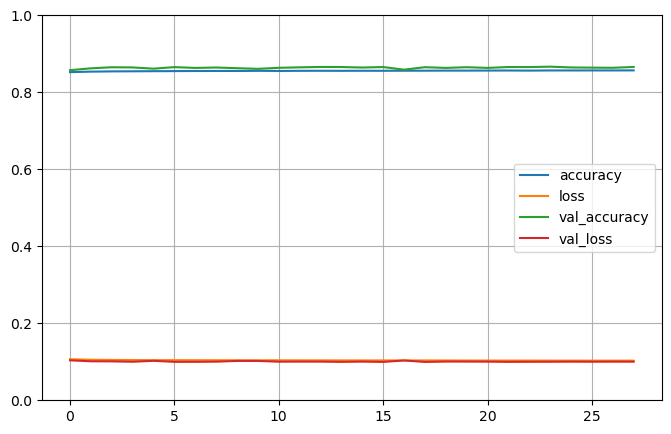

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5)) 
plt.grid(True)
plt.gca().set_ylim(0, 1)

In [36]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('model_10.h5')

/home/cao/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
def get_report(model, report_filename, size, sample_number_max):
    limit = size*(size-1)
    with open(report_filename, 'w+') as f:
        for i in range(1, sample_number_max+1):
            test_set_report = pd.read_csv(fr'./jump3_code/data for comparison/size{size}/size{size}_{i}.csv', index_col=0)
            X_test_report, y_test_report = prepare_data(test_set_report)
            y_test_report_pred = model.predict(X_test_report)
            precision1, recall1, _ = precision_recall_curve(y_test_report[:limit], y_test_report_pred[:limit])
            aupr1 = auc(recall1, precision1)
            
            precision2, recall2, _ = precision_recall_curve(y_test_report[limit:], y_test_report_pred[limit:])
            aupr2 = auc(recall2, precision2)
            f.write(f'{aupr1}\n')
            f.write(f'{aupr2}\n')

In [46]:
test_set_report = pd.read_csv(fr'./jump3_code/data for comparison/size10/size10_1.csv', index_col=0)
X_test_report, y_test_report = prepare_data(test_set_report)
X_test_report.shape

(180, 102)

In [48]:
X_valid.shape

(180000, 102)

In [58]:
get_report(model, './caocao/report/mlp_size10.txt', 10, 10)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


**Evaluate on the test set**

In [65]:
y_predicted = model.predict(X_test)

5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


In [100]:
X_test.shape

(180000, 103)

In [167]:
y_predicted = np.round(y_predicted)

In [139]:
sum(y_predicted)

array([5410.], dtype=float32)

In [168]:
result = get_performace(test_set, y_predicted)

In [171]:
performance = pd.DataFrame.from_dict(result, orient='index')
performance.head(10)

,precision,recall,structural
0,0.1236,0.7907,0.8611
1,0.1345,0.7115,0.8594
2,0.0945,0.7429,0.8567
3,0.1236,0.8095,0.8617
4,0.1345,0.9487,0.8667
5,0.1018,0.6829,0.8556
6,0.1709,0.8246,0.8678
7,0.1055,0.8286,0.8600
8,0.0727,0.6897,0.8533
9,0.1236,0.8095,0.8617


In [193]:
performance.to_csv(r'C:\caocao\gnw-master\ANN\single_size\test\performance\size10.csv')

**With imbalancing rounded**

In [192]:
predicted = get_round(y_predicted, 0.3)
result = get_performace(test_set, predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
performance.head(10)

,precision,recall,structural
0,0.5127,0.5663,0.8656
1,0.4545,0.5507,0.8600
2,0.5200,0.5697,0.8667
3,0.5200,0.5837,0.8700
4,0.5600,0.6087,0.8778
5,0.4727,0.5677,0.8644
6,0.4836,0.5278,0.8550
7,0.5091,0.5534,0.8622
8,0.4836,0.5612,0.8633
9,0.5018,0.5656,0.8650


In [181]:
predicted = get_round(y_predicted, 0.2)
result = get_performace(test_set, predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
performance.head(10)

,precision,recall,structural
0,0.6400,0.4324,0.8167
1,0.6655,0.4463,0.8228
2,0.6400,0.4619,0.8311
3,0.6509,0.4377,0.8189
4,0.6691,0.4706,0.8344
5,0.6145,0.4447,0.8239
6,0.6291,0.4261,0.8139
7,0.6400,0.4478,0.8244
8,0.6291,0.4413,0.8217
9,0.6473,0.4363,0.8183


**ROC curve**

In [69]:
thresholds = [i/100 for i in range(100, 0, -1)]
performances = []
for threshold in thresholds:
    predicted = get_round(y_predicted, threshold)
    result = get_performace(test_set, predicted)
    performance = pd.DataFrame.from_dict(result, orient='index')
    performances.append(performance)
    performance.to_csv(fr'./caocao/performance/size10_threshold_{threshold}.csv')

In [31]:
y_predicted

array([[0.06820707],
       [0.1902494 ],
       [0.26922196],
       ...,
       [0.00607832],
       [0.00508325],
       [0.00936213]], dtype=float32)

In [70]:
curves_info = {i:[[],[]] for i in range(100)}
for per in performances:
    for i in range(100):
        curves_info[i][0].append(per.iloc[i, 3])
        curves_info[i][1].append(per.iloc[i, 4])

In [73]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    'font.size': 12,              # Default font size for text
    'axes.titlesize': 20,         # Font size for axes titles
    'axes.labelsize': 15,         # Font size for x and y labels
    'xtick.labelsize': 12,        # Font size for x tick labels
    'ytick.labelsize': 12,        # Font size for y tick labels
    'legend.fontsize': 12,        # Font size for legend
    'figure.titlesize': 22        # Font size for figure title
})
plt.tick_params(axis='both',        # Apply changes to both x and y axes
                which='major',      # Apply changes to major ticks
                direction='inout',    # Ticks pointing outwards
                length=10,          # Length of ticks
                width=2           # Width of ticks
                #colors='red',       # Color of ticks
                #grid_color='black', # Color of gridlines
                #grid_alpha=0.5)     # Transparency of gridlines
               )
plt.xlim(0, 0.35)
plt.ylim(0, 0.8)
for k, v in curves_info.items():
    
    plt.plot(v[1], v[0], linewidth=3, marker='o', linestyle='dashed', color='#ff4f00')   
    plt.fill_between(v[1], v[0], color='#99ce3e', alpha=0.4)
    plt.text(0.2, 0.3, 'AUC', fontsize=14, color='#0d929a', ha='center', weight='bold')
    plt.text(0.07, 0.6, 'ROC', fontsize=14, color='#0d929a', ha='center',  weight='bold')
    plt.plot([0,v[1][-1]], [0, v[0][-1]], linewidth=3, linestyle='solid', color='#650000')
    plt.title(f'ROC curve - sample {k}')
    plt.xlabel('FP Rate')
    plt.ylabel('TP Rate')
    plt.savefig(fr'./caocao/performance/ROC/s10_{k}.png')
    plt.clf()

<Figure size 800x600 with 0 Axes>

**Average ROC curve**

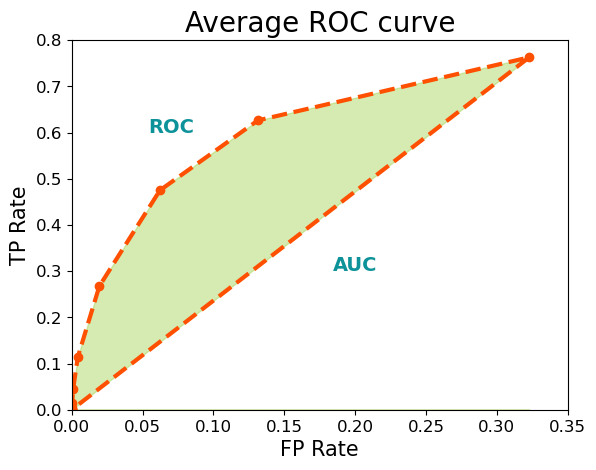

In [98]:
plt.clf()
plt.xlim(0, 0.35)
plt.ylim(0, 0.8)
x = [0 for _ in range(11)]
y = [0 for _ in range(11)]
for k, v in curves_info.items():
    for i in range(10):
        x[i]+=v[1][i]
        y[i]+=v[0][i]
x = [i/100 for i in x]
y = [i/100 for i in y]
plt.plot(x, y, linewidth=3, marker='o', linestyle='dashed', color='#ff4f00')
plt.fill_between(x, y, color='#99ce3e', alpha=0.4)
plt.text(0.2, 0.3, 'AUC', fontsize=14, color='#0d929a', ha='center', weight='bold')
plt.text(0.07, 0.6, 'ROC', fontsize=14, color='#0d929a', ha='center',  weight='bold')
plt.plot([0,x[-1]], [0, y[-1]], linewidth=3, linestyle='solid', color='#650000')
plt.title(f'Average ROC curve')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.savefig(fr'C:\caocao\gnw-master\ANN\single_size\test\performance\ROC\s10_average.png')

In [141]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

# Example data
y_true = np.array([0, 1, 1, 0, 1, 1, 0, 0, 1, 0])  # True binary labels
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.7, 0.6, 0.2, 0.3, 0.9, 0.4])  # Scores or probabilities

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_true, y_scores)

# Calculate AUPR
aupr = auc(recall, precision)

print(f"AUPR: {aupr:.4f}")


AUPR: 0.7381


**Test on DREAM4**

In [223]:
size10_1 = pd.read_csv(r'./caocao/Dream4/size10_1.csv', index_col=0)
size10_1.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step11,t_step12,t_step13,t_step14,t_step15,t_step16,t_step17,t_step18,t_step19,t_step20
0,10,0,G1,G2,1,0.666511,0.325775,0.177501,0.183885,0.093069,...,0.093721,0.144317,0.158025,0.090640,0.095929,0.125114,0.098533,0.082360,0.113119,0.078058
1,10,0,G1,G3,1,0.666511,0.325775,0.177501,0.183885,0.093069,...,0.345316,0.476338,0.352766,0.381792,0.402581,0.352010,0.454182,0.425455,0.316844,0.334017
2,10,0,G1,G4,1,0.666511,0.325775,0.177501,0.183885,0.093069,...,0.618386,0.623384,0.642924,0.744821,0.647759,0.788427,0.708663,0.700968,0.660231,0.669540
3,10,0,G1,G5,1,0.666511,0.325775,0.177501,0.183885,0.093069,...,0.485255,0.325796,0.263436,0.190667,0.127809,0.134015,0.139178,0.096002,0.138980,0.118167
4,10,0,G3,G4,1,0.355065,0.346411,0.571289,0.484977,0.343555,...,0.618386,0.623384,0.642924,0.744821,0.647759,0.788427,0.708663,0.700968,0.660231,0.669540


In [227]:
X_size10_1_gold, y_size10_1_gold = prepare_data(size10_1)

In [229]:
size10_1_predicted = model.predict(X_size10_1_gold)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [233]:
y_size10_1_gold

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [259]:
aver = {}
for j in range(1,6):
    size10 = pd.read_csv(fr'./caocao/Dream4/size10_{j}.csv', index_col=0)
    s=0
    for i in range(5):
        sample = size10[size10['sample']==i]
        X, y = prepare_data(sample)
        y_pre = model.predict(X)
        precision, recall, _ = precision_recall_curve(y, y_pre)
        aupr = auc(recall, precision)
        s+=aupr
        print(f'Net {j}, sample {i} ==> aupr = {aupr}')
    s/=5
    aver[f'Net {j}'] = s
print(aver)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Net 1, sample 0 ==> aupr = 0.16329326871427852
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 1, sample 1 ==> aupr = 0.1946713043487729
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Net 1, sample 2 ==> aupr = 0.16950577809871895
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 1, sample 3 ==> aupr = 0.2247685024407357
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 1, sample 4 ==> aupr = 0.3081175336695425
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Net 2, sample 0 ==> aupr = 0.2741949258430969
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 2, sample 1 ==> aupr = 0.28572234620333814
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 2, sample 2 ==> aupr = 0.3367916724580114
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 2, sample 3 ==> aupr = 0.4290268260448371
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 2, sample 4 ==> aupr = 0.21933352246716104
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 3, sample 0 ==> aupr = 0.1848338772410706
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Net 3, sample 1 ==> aupr = 0.18302